In [2]:
!pip install liac-arff

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11781 sha256=60e32bb3c199defe1477247e248662507cc54541d45dd3209b479b0ced1a0c34
  Stored in directory: c:\users\wd\appdata\local\pip\cache\wheels\93\f3\5b\658a9bddee916a5f4b84bdc1a4e0fabd22fb17947c2c9542e6
Successfully built liac-arff


In [5]:
import pandas as pd

# arff 파일을 직접 텍스트로 읽어서 데이터 부분만 파싱
with open("chronic_kidney_disease.arff", "r") as f:
    lines = f.readlines()

# @DATA 이후 부분만 추출
data_start = [i for i, line in enumerate(lines) if line.strip().upper() == '@DATA'][0] + 1
data_lines = lines[data_start:]

# 컬럼명 추출
columns = [line.split()[1] for line in lines if line.strip().upper().startswith('@ATTRIBUTE')]

# DataFrame 생성
from io import StringIO
data_str = ''.join(data_lines)
data_df = pd.read_csv(StringIO(data_str), header=None, names=columns, na_values='?')

print(data_df.head())
print(data_df.shape)

ParserError: Error tokenizing data. C error: Expected 25 fields in line 70, saw 26


In [6]:
import pandas as pd
from io import StringIO

with open("chronic_kidney_disease.arff", "r") as f:
    lines = f.readlines()

data_start = [i for i, line in enumerate(lines) if line.strip().upper() == '@DATA'][0] + 1
data_lines = lines[data_start:]

columns = [line.split()[1] for line in lines if line.strip().upper().startswith('@ATTRIBUTE')]

data_str = ''.join(data_lines)
data_df = pd.read_csv(StringIO(data_str), header=None, names=columns, na_values='?', on_bad_lines='skip')

print(data_df.head())
print(data_df.shape)


   'age'  'bp'   'sg'  'al'  'su'   'rbc'      'pc'       'pcc'        'ba'  \
0   48.0  80.0  1.020   1.0   0.0     NaN    normal  notpresent  notpresent   
1    7.0  50.0  1.020   4.0   0.0     NaN    normal  notpresent  notpresent   
2   62.0  80.0  1.010   2.0   3.0  normal    normal  notpresent  notpresent   
3   48.0  70.0  1.005   4.0   0.0  normal  abnormal     present  notpresent   
4   51.0  80.0  1.010   2.0   0.0  normal    normal  notpresent  notpresent   

   'bgr'  ...  'pcv'  'wbcc'  'rbcc'  'htn'  'dm' 'cad' 'appet' 'pe' 'ane'  \
0  121.0  ...     44    7800     5.2    yes   yes    no    good   no    no   
1    NaN  ...     38    6000     NaN     no    no    no    good   no    no   
2  423.0  ...     31    7500     NaN     no   yes    no    poor   no   yes   
3  117.0  ...     32    6700     3.9    yes    no    no    poor  yes   yes   
4  106.0  ...     35    7300     4.6     no    no    no    good   no    no   

  'class'  
0     ckd  
1     ckd  
2     ckd  
3     ck

In [7]:
data_df.columns = data_df.columns.str.replace("'", "").str.strip()
print(data_df.columns.tolist())

['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'class']


In [8]:
print(data_df.shape)
print(data_df.info())
print(data_df.isnull().sum())

(397, 25)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     388 non-null    float64
 1   bp      385 non-null    float64
 2   sg      350 non-null    float64
 3   al      351 non-null    float64
 4   su      348 non-null    float64
 5   rbc     247 non-null    object 
 6   pc      332 non-null    object 
 7   pcc     393 non-null    object 
 8   ba      393 non-null    object 
 9   bgr     354 non-null    float64
 10  bu      378 non-null    float64
 11  sc      380 non-null    float64
 12  sod     312 non-null    float64
 13  pot     311 non-null    float64
 14  hemo    345 non-null    float64
 15  pcv     328 non-null    object 
 16  wbcc    293 non-null    object 
 17  rbcc    268 non-null    object 
 18  htn     395 non-null    object 
 19  dm      395 non-null    object 
 20  cad     395 non-null    object 
 21  appet   396 non-null    objec

In [9]:
# pcv, wbcc, rbcc 숫자로 변환
for col in ['pcv', 'wbcc', 'rbcc']:
    data_df[col] = pd.to_numeric(data_df[col], errors='coerce')

print(data_df[['pcv', 'wbcc', 'rbcc']].dtypes)

pcv     float64
wbcc    float64
rbcc    float64
dtype: object


In [10]:
# 수치형 컬럼은 중앙값으로 채우기
num_cols = data_df.select_dtypes(include='float64').columns
data_df[num_cols] = data_df[num_cols].fillna(data_df[num_cols].median())

# 범주형 컬럼은 최빈값으로 채우기
obj_cols = data_df.select_dtypes(include='object').columns
for col in obj_cols:
    data_df[col] = data_df[col].fillna(data_df[col].mode()[0])

print(data_df.isnull().sum())

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64


C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1962340772.py:19: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1962340772.py:19: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1962340772.py:19: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1962340772.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1962340772.py:19: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1962340772.py:19: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WD

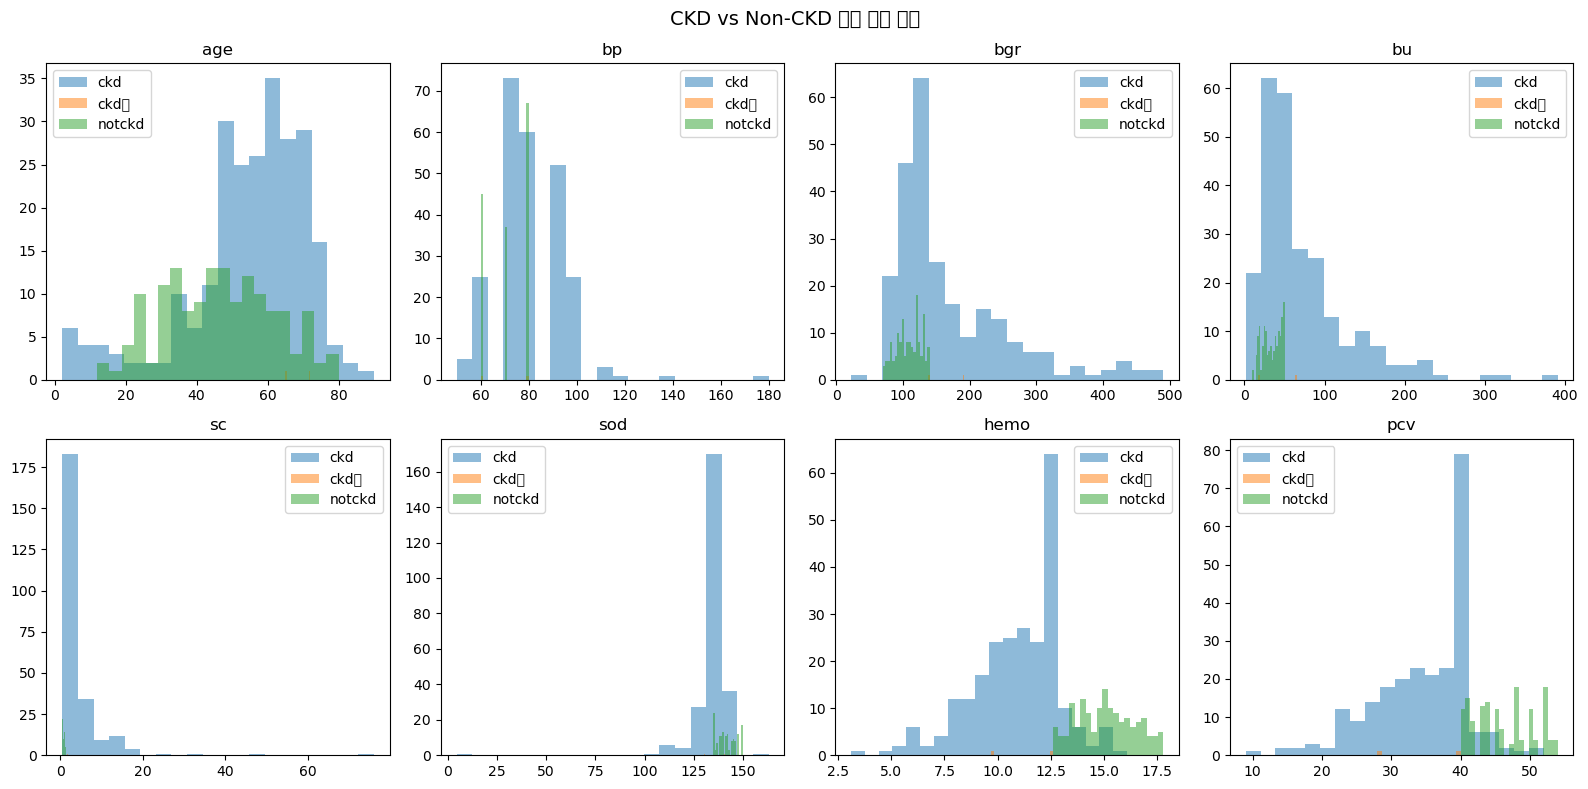

In [11]:
import matplotlib.pyplot as plt

# 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

# 주요 수치형 변수들 CKD 여부별 비교
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, group in data_df.groupby('class'):
        axes[i].hist(group[col], alpha=0.5, label=label, bins=20)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('CKD vs Non-CKD 주요 수치 비교', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
import matplotlib.pyplot as plt

# 윈도우 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

C:\Users\WD\AppData\Local\Temp\ipykernel_8508\2725908588.py:14: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\WD\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


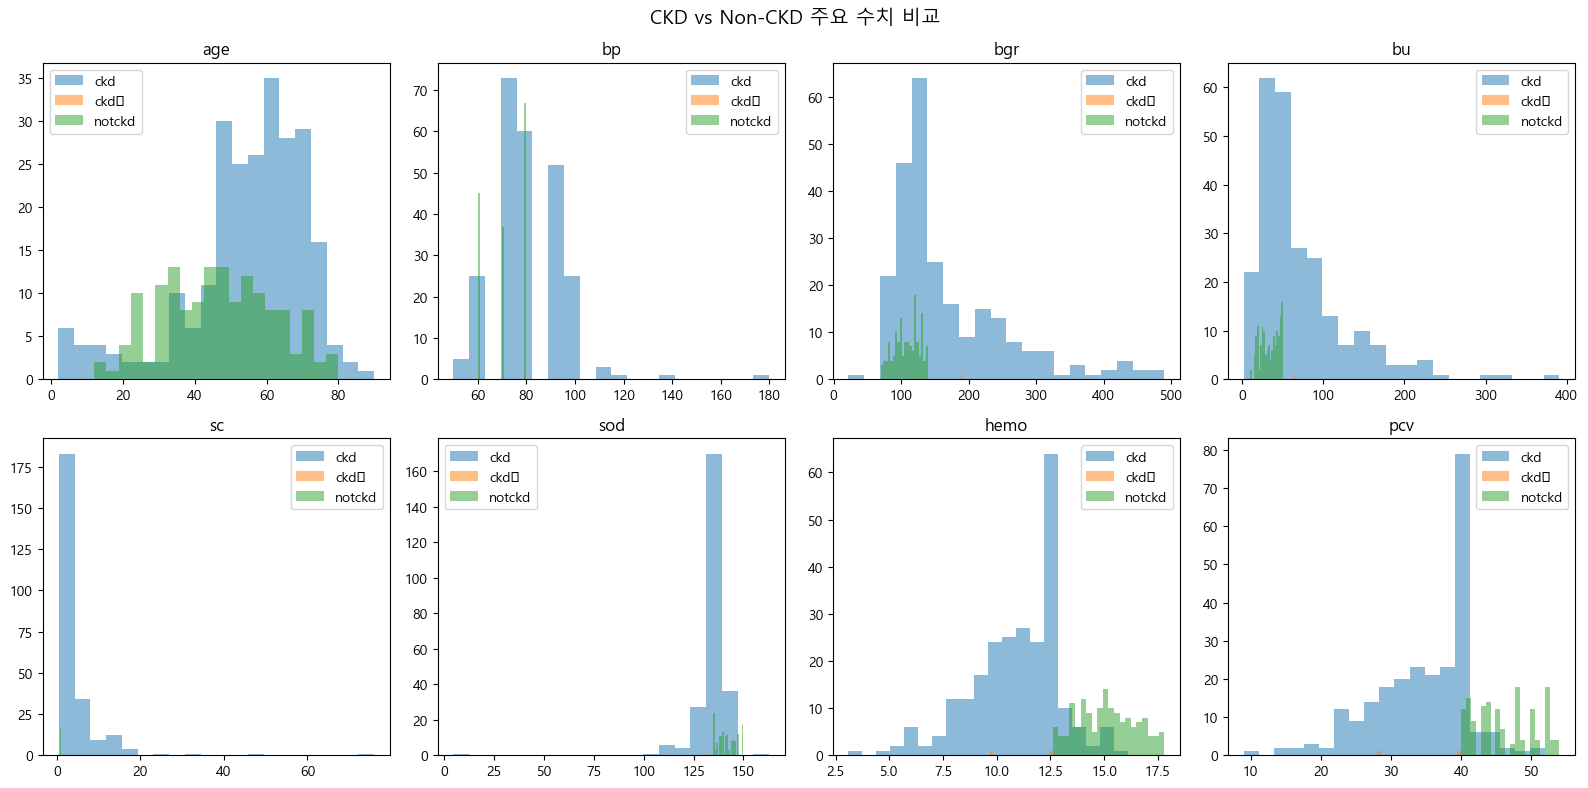

In [13]:
# 주요 수치형 변수들 CKD 여부별 비교
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, group in data_df.groupby('class'):
        axes[i].hist(group[col], alpha=0.5, label=label, bins=20)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('CKD vs Non-CKD 주요 수치 비교', fontsize=14)
plt.tight_layout()
plt.show()

C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1057826098.py:20: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\WD\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


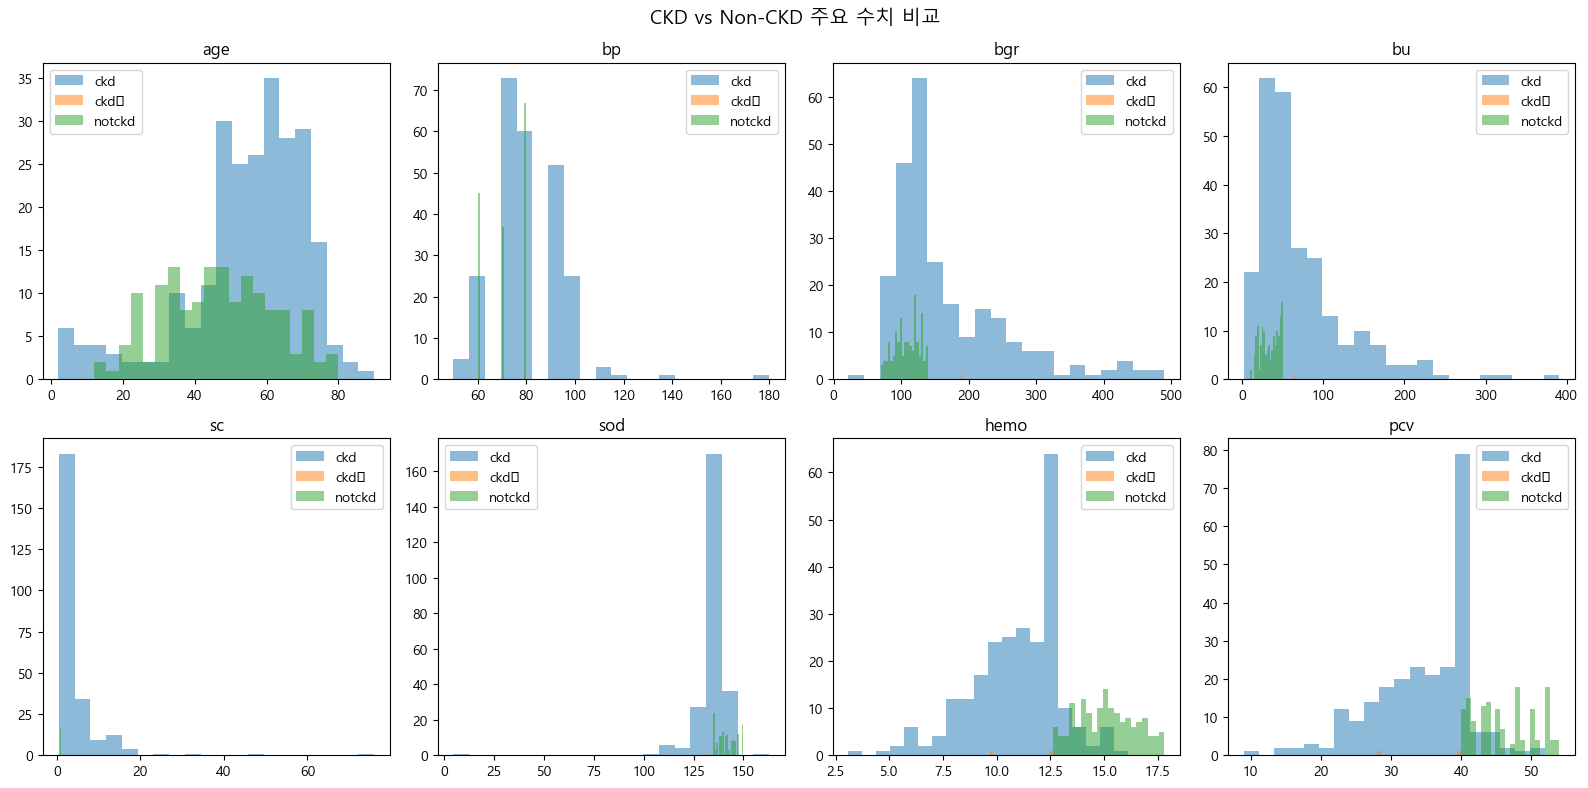

In [17]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 주요 수치형 변수들 CKD 여부별 비교
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, group in data_df.groupby('class'):
        axes[i].hist(group[col], alpha=0.5, label=label, bins=20)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('CKD vs Non-CKD 주요 수치 비교', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
plt.suptitle('CKD vs Non-CKD 주요 수치 비교', fontsize=14)

Text(0.5, 0.98, 'CKD vs Non-CKD 주요 수치 비교')

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

C:\Users\WD\AppData\Local\Temp\ipykernel_8508\1658653030.py:13: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\WD\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


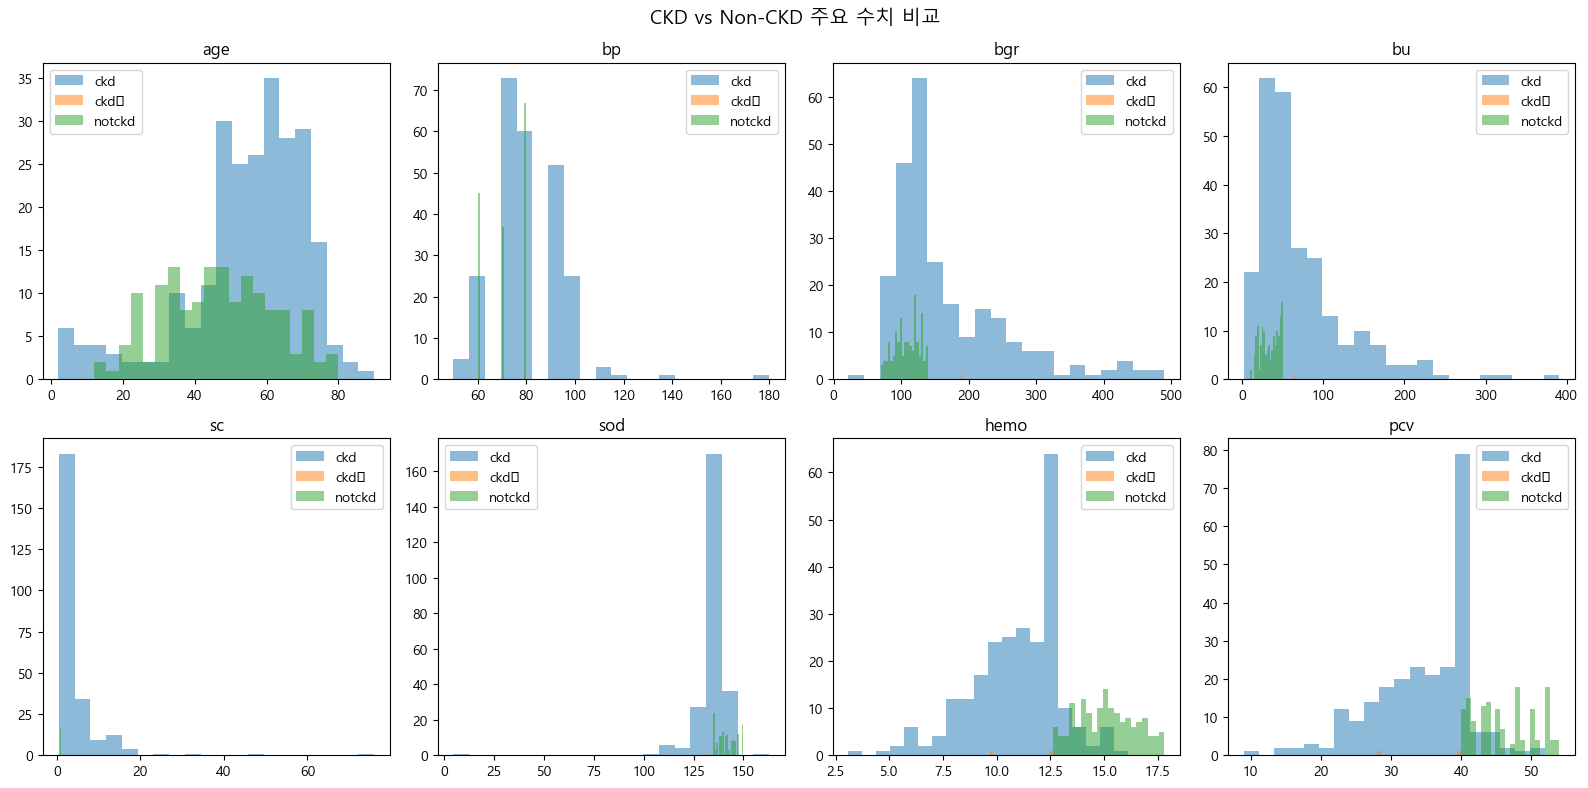

In [20]:
num_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'hemo', 'pcv']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, group in data_df.groupby('class'):
        axes[i].hist(group[col], alpha=0.5, label=label, bins=20)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('CKD vs Non-CKD 주요 수치 비교', fontsize=14)
plt.tight_layout()
plt.show()

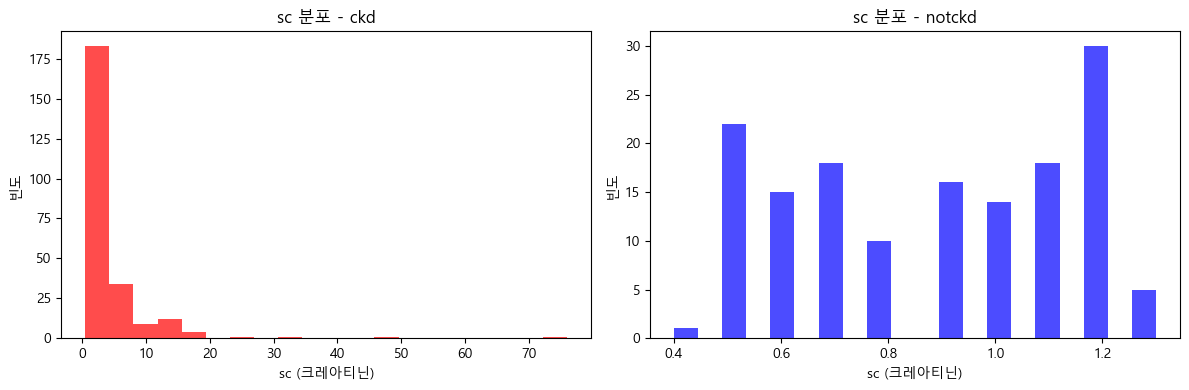

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, label in zip(axes, ['ckd', 'notckd']):
    subset = data_df[data_df['class'] == label]
    ax.hist(subset['sc'], bins=20, color='red' if label == 'ckd' else 'blue', alpha=0.7)
    ax.set_title(f'sc 분포 - {label}')
    ax.set_xlabel('sc (크레아티닌)')
    ax.set_ylabel('빈도')

plt.tight_layout()
plt.show()

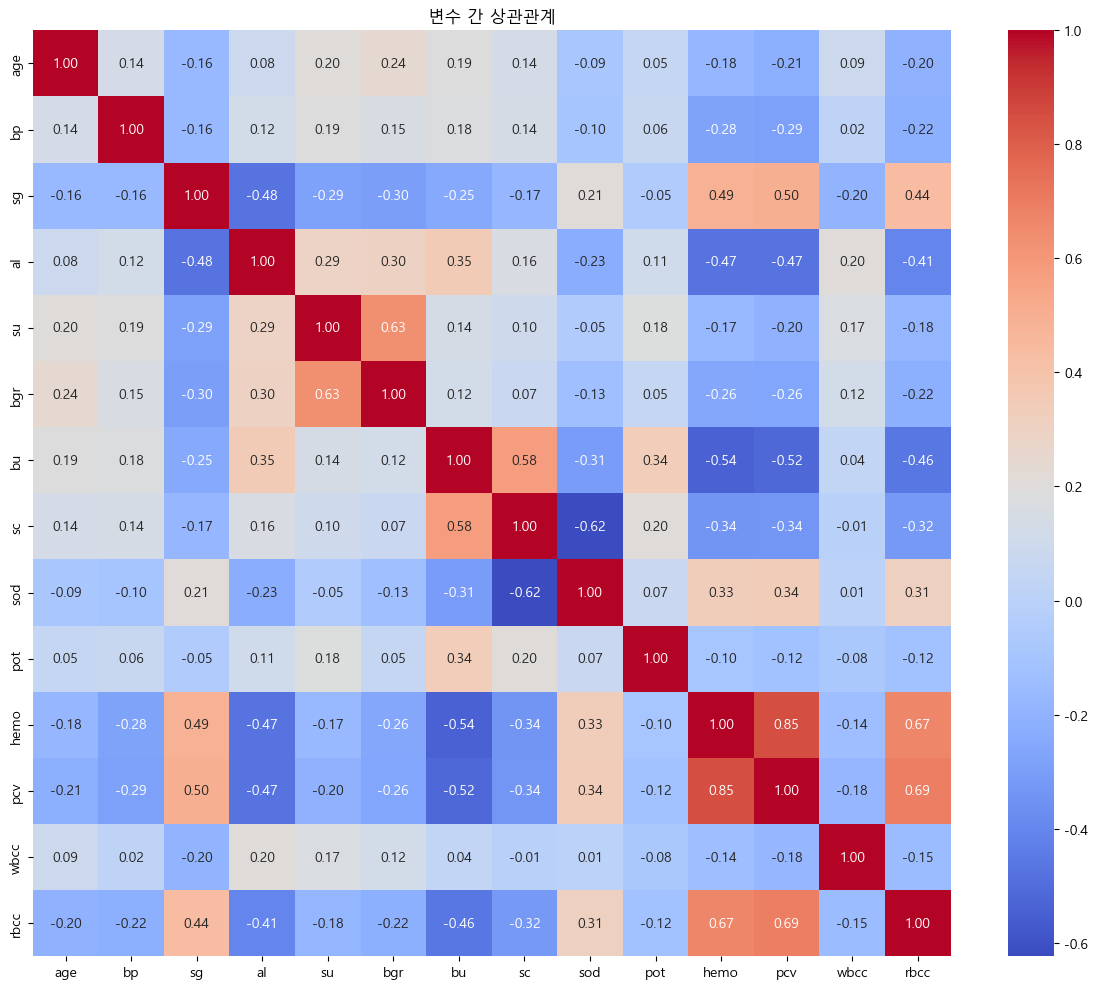

In [22]:
import seaborn as sns

plt.figure(figsize=(12, 10))
num_cols = data_df.select_dtypes(include='float64').columns
sns.heatmap(data_df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('변수 간 상관관계')
plt.tight_layout()
plt.show()

강한 양의 상관관계 (빨간색)

hemo - pcv (0.85) : 헤모글로빈이 높으면 적혈구용적률도 높음 → 당연한 결과
hemo - rbcc (0.67), pcv - rbcc (0.69) : 적혈구 관련 지표들끼리 묶임
su - bgr (0.63) : 요당이 높으면 혈당도 높음 → 당뇨 연관성
bu - sc (0.58) : 요소와 크레아티닌 → 둘 다 신장 노폐물 지표라 같이 올라감

강한 음의 상관관계 (파란색)

sc - sod (-0.62) : 크레아티닌 올라가면 나트륨 떨어짐 → 신장 기능 악화 패턴
bu - hemo (-0.54), bu - pcv (-0.52) : 요소 올라가면 빈혈 심해짐 → CKD 진행 패턴

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# object 타입 컬럼 전부 숫자로 변환
obj_cols = data_df.select_dtypes(include='object').columns
for col in obj_cols:
    data_df[col] = le.fit_transform(data_df[col])

print(data_df.head())
print(data_df.dtypes)

    age    bp     sg   al   su  rbc  pc  pcc  ba    bgr  ...   pcv    wbcc  \
0  48.0  80.0  1.020  1.0  0.0    1   1    0   0  121.0  ...  44.0  7800.0   
1   7.0  50.0  1.020  4.0  0.0    1   1    0   0  121.0  ...  38.0  6000.0   
2  62.0  80.0  1.010  2.0  3.0    1   1    0   0  423.0  ...  31.0  7500.0   
3  48.0  70.0  1.005  4.0  0.0    1   0    1   0  117.0  ...  32.0  6700.0   
4  51.0  80.0  1.010  2.0  0.0    1   1    0   0  106.0  ...  35.0  7300.0   

   rbcc  htn  dm  cad  appet  pe  ane  class  
0   5.2    1   4    1      0   0    0      0  
1   4.8    0   3    1      0   0    0      0  
2   4.8    0   4    1      1   0    1      0  
3   3.9    1   3    1      1   1    1      0  
4   4.6    0   3    1      0   0    0      0  

[5 rows x 25 columns]
age      float64
bp       float64
sg       float64
al       float64
su       float64
rbc        int64
pc         int64
pcc        int64
ba         int64
bgr      float64
bu       float64
sc       float64
sod      float64
pot  

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# X: 입력 변수, y: 예측할 변수(CKD 여부)
X = data_df.drop('class', axis=1)
y = data_df['class']

# 학습용 80%, 테스트용 20% 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 예측 및 정확도 확인
y_pred = model.predict(X_test)
print("정확도:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

정확도: 0.9625
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        50
           1       0.00      0.00      0.00         1
           2       1.00      0.93      0.96        29

    accuracy                           0.96        80
   macro avg       0.65      0.64      0.65        80
weighted avg       0.95      0.96      0.96        80



C:\Users\WD\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\WD\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\WD\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [25]:
print(data_df['class'].value_counts())

class
0    246
2    149
1      2
Name: count, dtype: int64


In [26]:
# LabelEncoder 적용 전 원본 값 확인
with open("chronic_kidney_disease.arff", "r") as f:
    lines = f.readlines()

data_start = [i for i, line in enumerate(lines) if line.strip().upper() == '@DATA'][0] + 1
data_lines = lines[data_start:]

columns = [line.split()[1] for line in lines if line.strip().upper().startswith('@ATTRIBUTE')]

from io import StringIO
import pandas as pd
data_str = ''.join(data_lines)
raw_df = pd.read_csv(StringIO(data_str), header=None, names=columns, na_values='?', on_bad_lines='skip')
raw_df.columns = raw_df.columns.str.replace("'", "").str.strip()

print(raw_df['class'].value_counts())

class
ckd       246
notckd    149
ckd\t       2
Name: count, dtype: int64


In [27]:
# ckd\t를 ckd로 교체
data_df['class'] = data_df['class'].replace({1: 0})

print(data_df['class'].value_counts())

class
0    248
2    149
Name: count, dtype: int64


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = data_df.drop('class', axis=1)
y = data_df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("정확도:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

정확도: 0.975
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        51
           2       1.00      0.93      0.96        29

    accuracy                           0.97        80
   macro avg       0.98      0.97      0.97        80
weighted avg       0.98      0.97      0.97        80



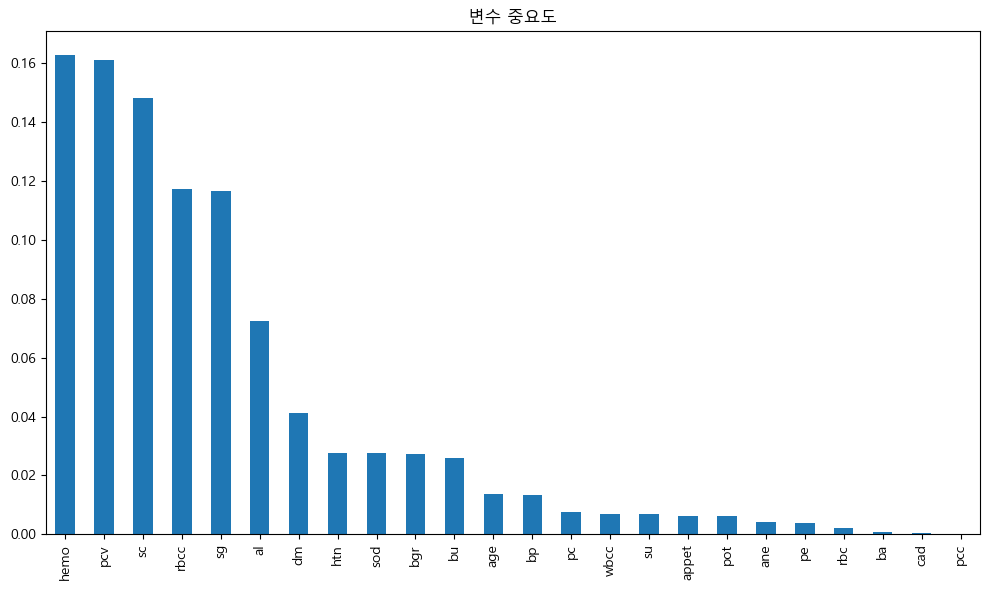

In [29]:
# 변수 중요도 시각화
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('변수 중요도')
plt.tight_layout()
plt.show()

상위 5개 중요 변수:

hemo(헤모글로빈), pcv(적혈구용적률) : 신장이 EPO 분비를 못해서 생기는 빈혈 지표
sc(크레아티닌) : 신장 기능의 핵심 지표
rbcc(적혈구 수) : 빈혈 관련
sg(요비중) : 신장의 소변 농축 능력

흥미로운 점:

빈혈 관련 지표(hemo, pcv, rbcc)가 크레아티닌보다 중요도가 높다
이건 이 데이터셋에서 빈혈이 CKD를 구분하는 데 매우 강력한 신호
반면 ba, cad, pcc 는 중요도가 거의 0에 가까움

In [30]:
import numpy as np

def predict_ckd(age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc, htn, dm, cad, appet, pe, ane):
    
    patient = np.array([[age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc, htn, dm, cad, appet, pe, ane]])
    
    prediction = model.predict(patient)[0]
    probability = model.predict_proba(patient)[0]
    
    if prediction == 0:
        result = "CKD (만성신장질환)"
    else:
        result = "정상 (Non-CKD)"
    
    print(f"예측 결과: {result}")
    print(f"CKD 확률: {probability[0]*100:.1f}%")
    print(f"정상 확률: {probability[1]*100:.1f}%")

# 예시 환자 데이터 입력
predict_ckd(
    age=50, bp=80, sg=1.020, al=1, su=0,
    rbc=1, pc=1, pcc=0, ba=0,
    bgr=121, bu=36, sc=1.2,
    sod=135, pot=4.5, hemo=15.0,
    pcv=44, wbcc=7800, rbcc=5.2,
    htn=1, dm=3, cad=1, appet=0, pe=0, ane=0
)

예측 결과: CKD (만성신장질환)
CKD 확률: 53.0%
정상 확률: 47.0%


C:\Users\WD\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\WD\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [31]:
import numpy as np

def predict_ckd(age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc, htn, dm, cad, appet, pe, ane):
    
    patient = pd.DataFrame([[age, bp, sg, al, su, rbc, pc, pcc, ba, bgr, bu, sc, sod, pot, hemo, pcv, wbcc, rbcc, htn, dm, cad, appet, pe, ane]], 
                           columns=X.columns)
    
    prediction = model.predict(patient)[0]
    probability = model.predict_proba(patient)[0]
    
    if prediction == 0:
        result = "CKD (만성신장질환)"
    else:
        result = "정상 (Non-CKD)"
    
    print(f"예측 결과: {result}")
    print(f"CKD 확률: {probability[0]*100:.1f}%")
    print(f"정상 확률: {probability[1]*100:.1f}%")

# 예시 환자 데이터 입력
predict_ckd(
    age=50, bp=80, sg=1.020, al=1, su=0,
    rbc=1, pc=1, pcc=0, ba=0,
    bgr=121, bu=36, sc=1.2,
    sod=135, pot=4.5, hemo=15.0,
    pcv=44, wbcc=7800, rbcc=5.2,
    htn=1, dm=3, cad=1, appet=0, pe=0, ane=0
)

예측 결과: CKD (만성신장질환)
CKD 확률: 53.0%
정상 확률: 47.0%


In [32]:
print(raw_df['dm'].value_counts())

dm
no       257
yes      132
\tno       3
\tyes      2
 yes       1
Name: count, dtype: int64
